In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df=pd.read_csv('train.csv')
train_df.describe()
train_df.info()
train_df.shape

C:\Users\Anshit\AppData\Local\Temp\ipykernel_25628\1584024045.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df=pd.read_csv('train.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


(1017209, 9)

In [3]:
#Checking for missing data
train_df.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [4]:
train_df.head(5)
type(train_df["Date"])

pandas.core.series.Series

In [5]:
store_df=pd.read_csv('store.csv')
store_df.info()
store_df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Peform EDA on the Datasets
 train.csv and store.csv

In [6]:
merged_df=pd.merge(train_df,store_df,on='Store',how='left')
merged_df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
#Modify the data types of the columns
merged_df['Date']=pd.to_datetime(merged_df['Date'])
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['WeekOfYear'] = merged_df['Date'].dt.isocalendar().week
day_map = {
    1:"Monday",
    2:"Tuesday",
    3:"Wednesday",
    4:"Thursday",
    5:"Friday",
    6:"Saturday",
    7:"Sunday"
}

merged_df["DayName"] = merged_df["DayOfWeek"].map(day_map)
merged_df.info()
merged_df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 23 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,DayName
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,31,Friday
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,Friday
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,Friday
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,31,Friday
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,31,Friday


Visualising Sales Distribution for Stores

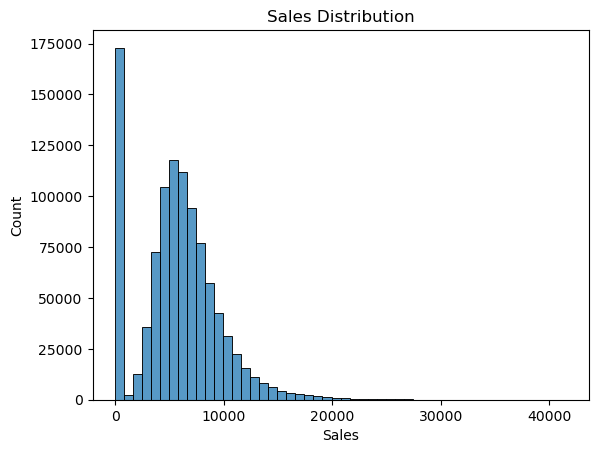

In [8]:
sns.histplot(merged_df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

We can see the right-skewdness of the distribution

Handling missing values using the median imputation

In [9]:
merged_df['CompetitionDistance'].fillna(merged_df['CompetitionDistance'].median(), inplace=True)
#IF missing competitor data
merged_df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
merged_df['CompetitionOpenSinceYear'].fillna(0, inplace=True)
#If missing Promo details
merged_df['Promo2SinceWeek'].fillna(0, inplace=True)
merged_df['Promo2SinceYear'].fillna(0, inplace=True)
#Handling missing values in categorical columns
merged_df['PromoInterval'].fillna("None", inplace=True)




C:\Users\Anshit\AppData\Local\Temp\ipykernel_25628\4262586037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['CompetitionDistance'].fillna(merged_df['CompetitionDistance'].median(), inplace=True)
C:\Users\Anshit\AppData\Local\Temp\ipykernel_25628\4262586037.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

Remove Closed Stores to prevent Bias

In [10]:
merged_df = merged_df[merged_df["Open"] == 1]

Convert Categorical Variables

In [11]:
categorical_cols = ["StoreType","Assortment","StateHoliday"]

for col in categorical_cols:
    merged_df[col] = merged_df[col].astype("category")

Feature Engineering

In [12]:
merged_df["IsWeekend"] = merged_df["DayOfWeek"].isin([6,7]).astype(int)

Trend Analysis

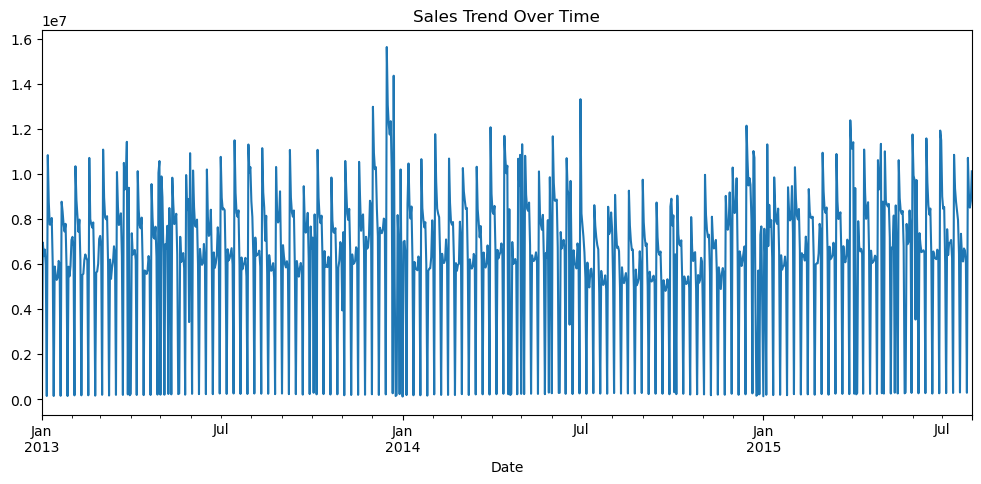

In [13]:
daily_sales = merged_df.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

Monthly Seasonality


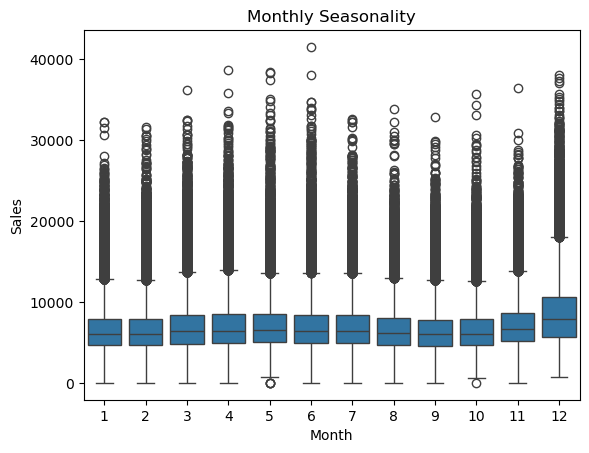

In [14]:
sns.boxplot(x="Month", y="Sales", data=merged_df)
plt.title("Monthly Seasonality")
plt.show()

Weekly Seasonality

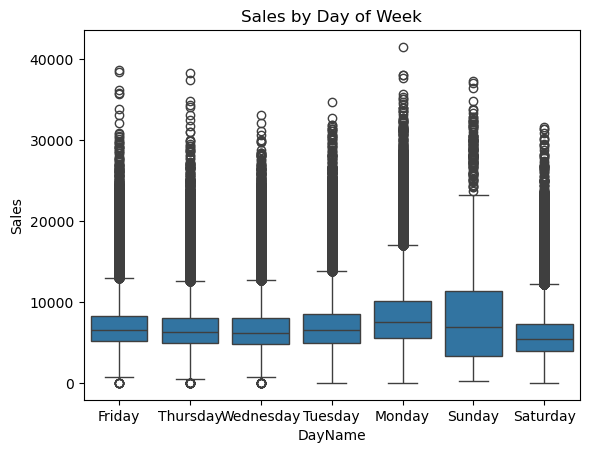

In [15]:
sns.boxplot(x="DayName", y="Sales", data=merged_df)
plt.title("Sales by Day of Week")
plt.show()

Impact on Promo on Sales

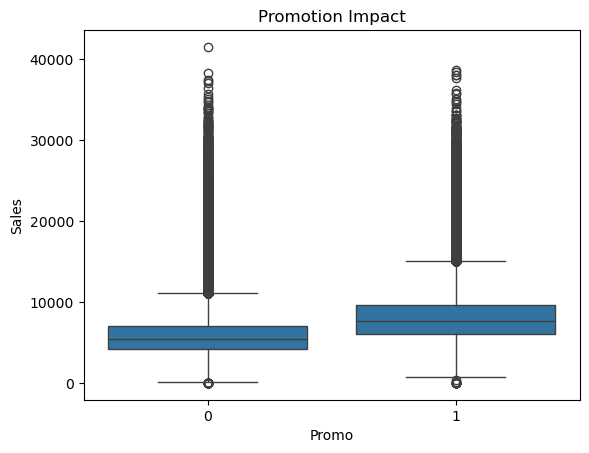

In [16]:
sns.boxplot(x="Promo", y="Sales", data=merged_df)
plt.title("Promotion Impact")
plt.show()

Customer Analysis

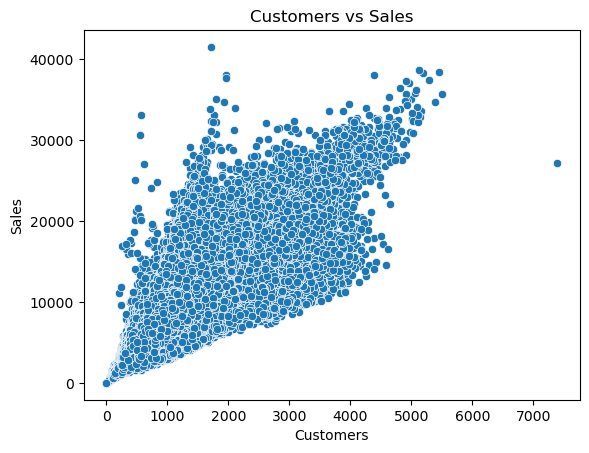

In [17]:
sns.scatterplot(x="Customers", y="Sales", data=merged_df)
plt.title("Customers vs Sales")
plt.show()

Store type analysis

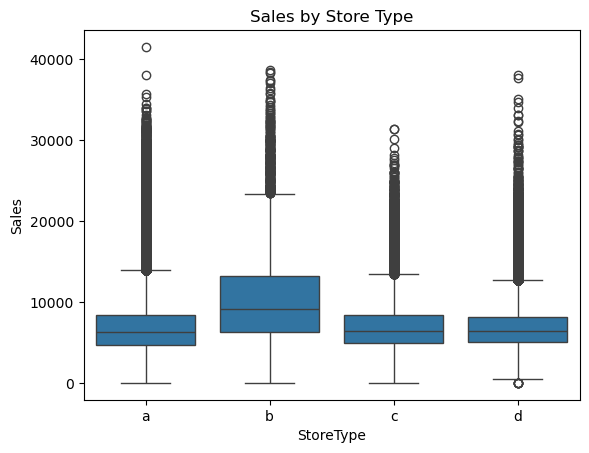

In [18]:
sns.boxplot(x="StoreType", y="Sales", data=merged_df)
plt.title("Sales by Store Type")
plt.show()

Correlation heat-map

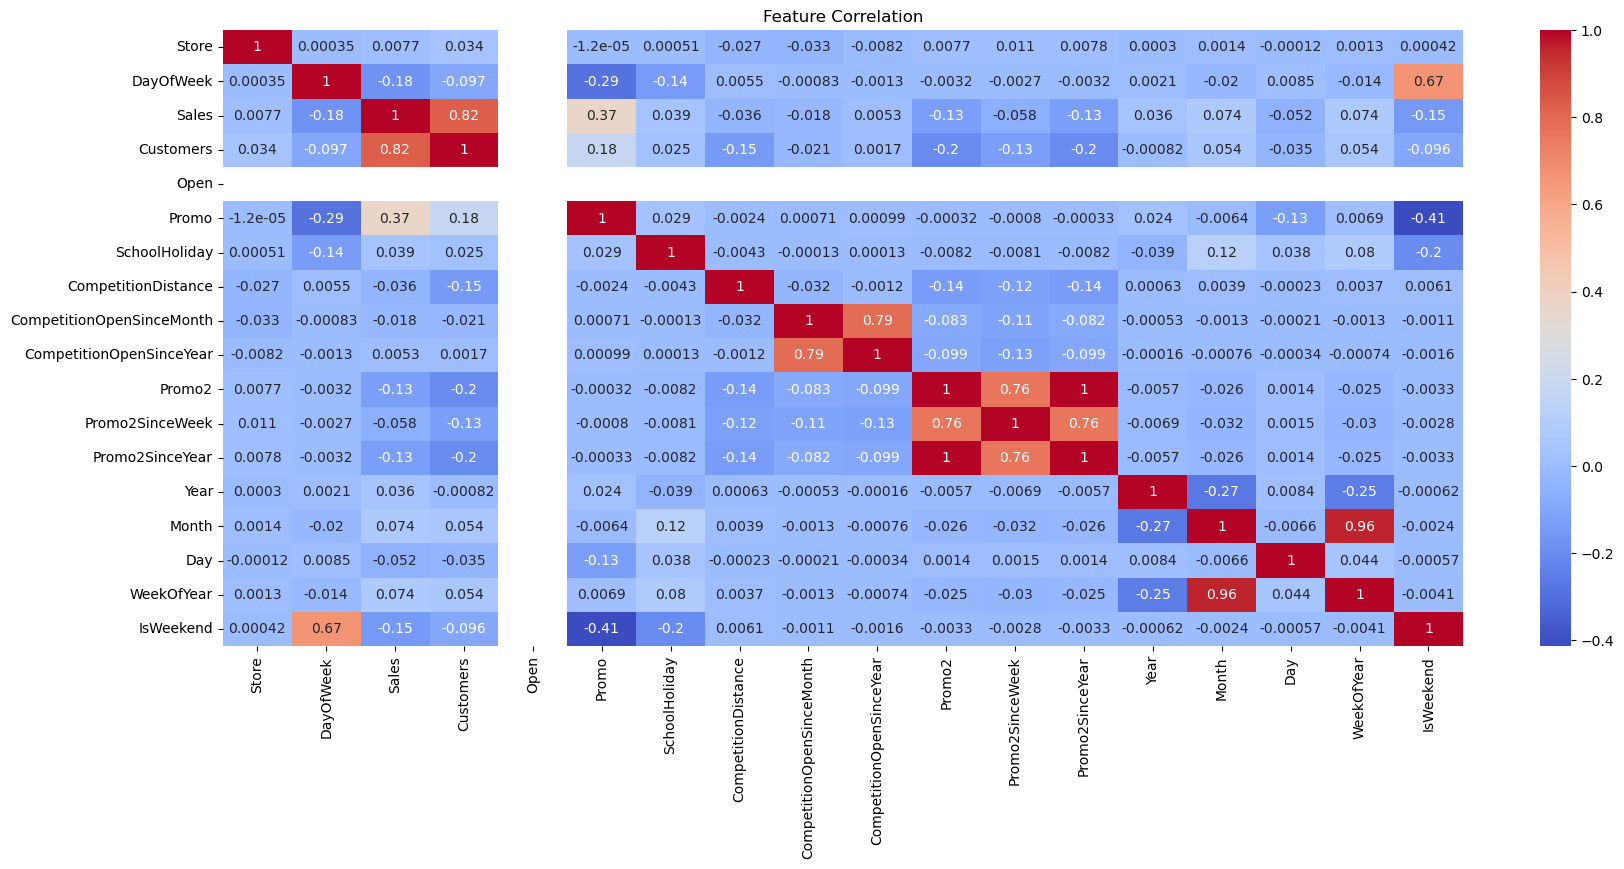

In [19]:
corr = merged_df.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(corr, cmap="coolwarm",annot=True)
plt.title("Feature Correlation")
plt.show()

Evaluating using LR as baseline Model

In [20]:
3#Log differencing
merged_df["log_sales"] = np.log1p(merged_df["Sales"])

In [21]:
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.model_selection import train_test_split
# Drop 'Sales', 'log_sales', and 'Date' as they are either target or not a feature for the model
X = merged_df.drop(["Sales","log_sales","Date"], axis=1)
y = merged_df["log_sales"]

# Identify categorical columns for one-hot encoding
categorical_cols_to_encode = ["StoreType", "Assortment", "StateHoliday", "PromoInterval", "DayName"]

# Apply one-hot encoding to the categorical columns
X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.22213588805781997
R2 Score: 0.7358937818746728


In [23]:
pred_sales = np.expm1(y_pred)
actual_sales = np.expm1(y_test)
rmse_sales = np.sqrt(mean_squared_error(actual_sales, pred_sales))
print(rmse_sales)

3144.4933616599114


## XGBoost Model

In [24]:
import time
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

def evaluate(model_name, y_true, y_pred_log):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_log))
    r2 = r2_score(y_true, y_pred_log)

    pred_sales = np.expm1(y_pred_log)
    actual_sales = np.expm1(y_true)
    rmse_sales = np.sqrt(mean_squared_error(actual_sales, pred_sales))
    r2_sales = r2_score(actual_sales, pred_sales)
    mae_sales = np.mean(np.abs(actual_sales - pred_sales))
    mape = np.mean(np.abs((actual_sales - pred_sales) / (actual_sales + 1e-9))) * 100

    print(f"\n--- {model_name} Evaluation ---")
    print(f"Log RMSE:           {rmse:.4f}")
    print(f"Log R2 Score:       {r2:.4f}")
    print(f"Actual Sales RMSE:  {rmse_sales:,.2f}")
    print(f"Actual Sales R2:    {r2_sales:.4f}")
    print(f"Actual Sales MAE:   {mae_sales:,.2f}")
    print(f"MAPE:               {mape:.2f}%")
    return {"rmse": rmse, "r2": r2, "rmse_sales": rmse_sales,
            "r2_sales": r2_sales, "mae_sales": mae_sales, "mape": mape}

# ── Train XGBoost ─────────────────────────────────────────────────────────────
print("⏳ Training XGBoost...")
start = time.time()

xgb_model = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 100
)

elapsed = (time.time() - start) / 60
print(f"\n✓ Done in {elapsed:.1f} mins")

xgb_preds = xgb_model.predict(X_test)
r_xgb = evaluate("XGBoost", y_test, xgb_preds)


⏳ Training XGBoost...
[0]	validation_0-rmse:0.42609
[100]	validation_0-rmse:0.13781
[200]	validation_0-rmse:0.12095
[300]	validation_0-rmse:0.10785
[400]	validation_0-rmse:0.09817
[499]	validation_0-rmse:0.09187

✓ Done in 1.3 mins

--- XGBoost Evaluation ---
Log RMSE:           0.0919
Log R2 Score:       0.9548
Actual Sales RMSE:  577.96
Actual Sales R2:    0.9654
Actual Sales MAE:   403.30
MAPE:               1776975437.67%


## Actual vs Predicted Plots

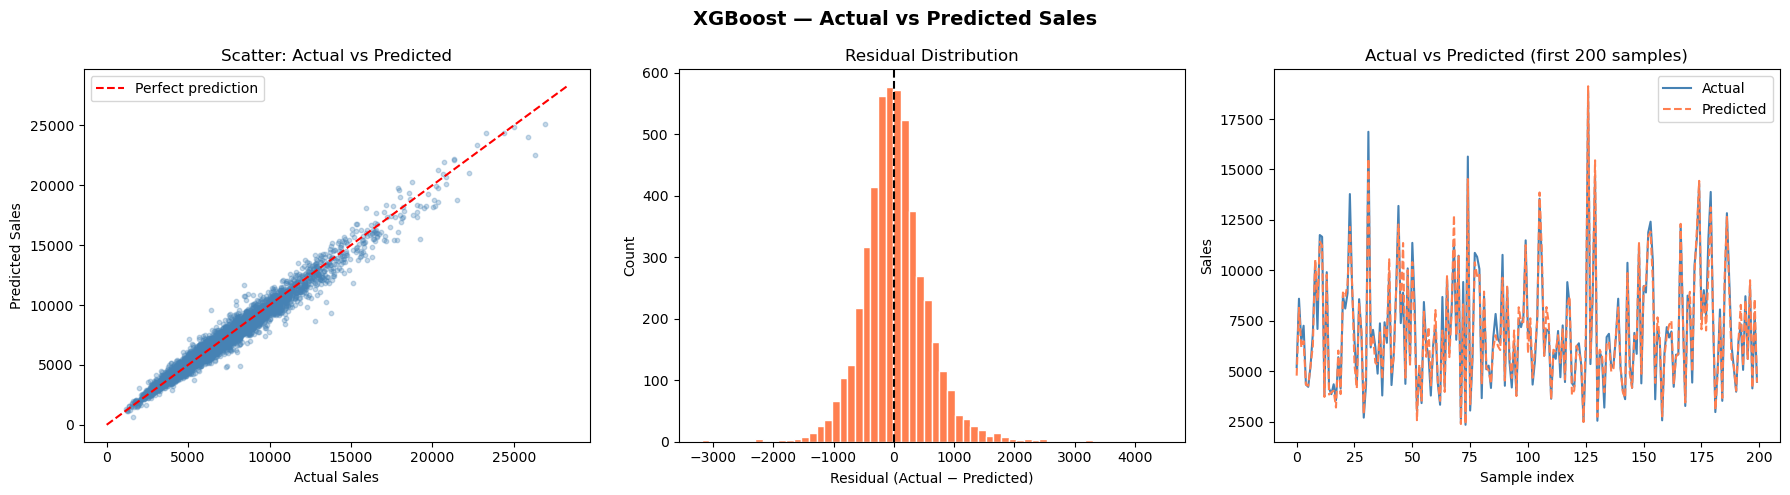

Plot saved → actual_vs_predicted.png ✓


In [25]:
actual_sales = np.expm1(y_test)
pred_sales   = np.maximum(np.expm1(xgb_preds), 0)

# Sample 5000 points for scatter readability
idx = np.random.choice(len(actual_sales), size=min(5000, len(actual_sales)), replace=False)
act_sample  = np.array(actual_sales)[idx]
pred_sample = np.array(pred_sales)[idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — Actual vs Predicted Sales", fontsize=14, fontweight='bold')

# Plot 1: Scatter
axes[0].scatter(act_sample, pred_sample, alpha=0.3, s=10, color='steelblue')
lim = max(act_sample.max(), pred_sample.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title("Scatter: Actual vs Predicted")
axes[0].legend()

# Plot 2: Residual distribution
residuals = act_sample - pred_sample
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel("Residual (Actual − Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

# Plot 3: Time-series slice (first 200 test samples)
n_show = 200
axes[2].plot(range(n_show), np.array(actual_sales)[:n_show], label='Actual',    color='steelblue', lw=1.5)
axes[2].plot(range(n_show), np.array(pred_sales)[:n_show],   label='Predicted', color='coral',     lw=1.5, linestyle='--')
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Sales")
axes[2].set_title("Actual vs Predicted (first 200 samples)")
axes[2].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → actual_vs_predicted.png ✓")


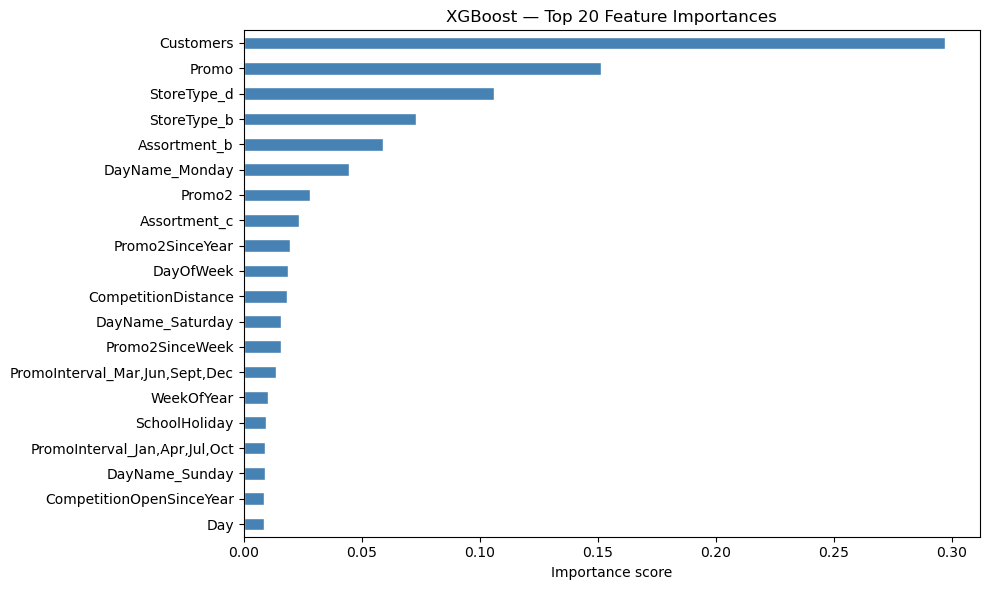

Feature importance plot saved ✓


In [26]:
# Feature Importance — Top 20
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("XGBoost — Top 20 Feature Importances")
plt.xlabel("Importance score")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved ✓")


## Save Model for Deployment

In [27]:
# Save model
joblib.dump(xgb_model, 'xgb_model.pkl')

# Save feature column order (critical for Streamlit alignment)
joblib.dump(X_train.columns.tolist(), 'feature_columns.pkl')

# Save evaluation metrics for Streamlit display
model_stats = {
    'rmse_log'   : round(r_xgb['rmse'], 4),
    'r2_log'     : round(r_xgb['r2'], 4),
    'rmse_actual': round(float(r_xgb['rmse_sales']), 2),
    'r2_actual'  : round(float(r_xgb['r2_sales']), 4),
    'mae_actual' : round(float(r_xgb['mae_sales']), 2),
    'mape'       : round(float(r_xgb['mape']), 2),
}
joblib.dump(model_stats, 'model_stats.pkl')

print("✓ xgb_model.pkl        — XGBoost model")
print("✓ feature_columns.pkl  — feature column order")
print("✓ model_stats.pkl      — evaluation metrics")
print("✓ actual_vs_predicted.png")
print("✓ feature_importance.png")


✓ xgb_model.pkl        — XGBoost model
✓ feature_columns.pkl  — feature column order
✓ model_stats.pkl      — evaluation metrics
✓ actual_vs_predicted.png
✓ feature_importance.png


## Download Files (Colab)

In [28]:
from google.colab import files
import os

for fname in ['xgb_model.pkl', 'feature_columns.pkl', 'model_stats.pkl',
              'actual_vs_predicted.png', 'feature_importance.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f"Downloaded: {fname}")


ModuleNotFoundError: No module named 'google.colab'